# Ejercicios prácticos - Módulo 7

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import bambi as bmb
import preliz as pz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1. Para el ejemplo de la ?fig-ExpQuad, asegúrese de comprender la relación entre los datos de entrada y la matriz de covarianza generada. Intente utilizar otra entrada como `data = np.random.normal(size=4)`.

Primero se define la función vista en el módulo, `exp_quad_kernel`. Esta representa al Kernel cuadrático exponencial:

In [ ]:
def exp_quad_kernel(x, xi, ℓ=1):
    """kernel cuadrático exponencial"""
    return np.array([np.exp(-(x-x_i)**2 / (2*ℓ**2)) for x_i in xi])


labels = ["A", "B", "C", "D"]
datos = np.random.normal(size=4)
cov = exp_quad_kernel(datos, datos, 1)

El código es similar al visto en el módulo con la variación de que se generan 4 datos en lugar de 3, tal y como lo sugiere el enunciado. Ahora procedemos a generar de vuelta el gráfico de la matriz de covarianza:

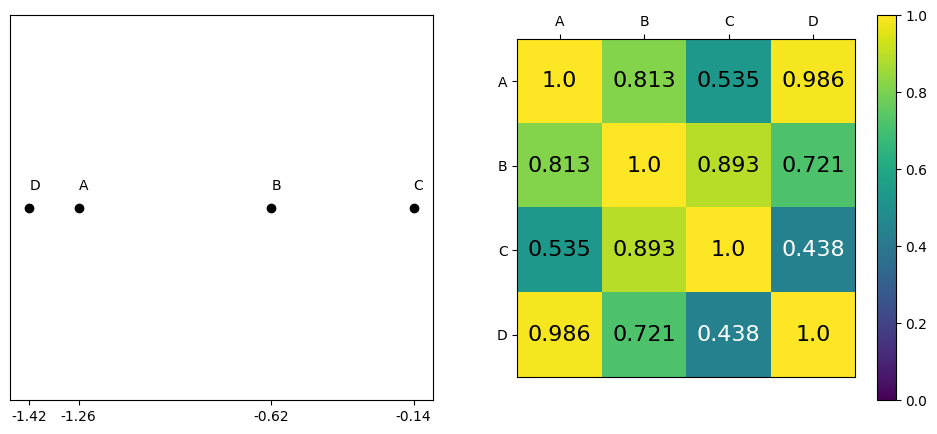

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = np.ravel(ax)

ax[0].plot(datos, np.zeros_like(datos), 'ko')
ax[0].set_yticks([])
for i, l in zip(datos, labels):
    ax[0].text(i, 0+0.005, l)
ax[0].set_xticks(datos)
ax[0].set_xticklabels(np.round(datos, 2))

ax[1].grid(False)
im = ax[1].imshow(cov, vmin=0, vmax=1)
colors = ['w', 'k']
for i in range(len(cov)):
    for j in range(len(cov)):
        ax[1].text(j, i, round(cov[i, j], 3),
                   color=colors[int(im.norm(cov[i, j]) > 0.5)],
                   ha='center', va='center', fontdict={'size': 16})
ax[1].set_xticks(range(len(datos)), labels)
ax[1].set_yticks(range(len(datos)), labels)
ax[1].xaxis.tick_top()
fig.colorbar(im, ax=ax[1])

plt.show()

La interpretación que se le puede dar consiste en el hecho de que **el Kernel mide distancia entre puntos**, eso hará que la matriz de covarianza muestre valores cercanos a 1 para puntos que se encuentren cerca entre sí (según la distancia euclidiana). En este caso se generaron 4 muestras aleatorias y 3 de ellas (B, D y A según la figura) están bastante cerca entre sí, eso hace que luego en la matriz de covarianza se vea una gran correlación entre dichos puntos.

### 2. Vuelva a ejecutar el código que genera la ?fig-ExpQuad_ell y aumente la cantidad de muestras obtenidas del GP anterior a alrededor de 200. En la figura original, la cantidad de muestras es 2. ¿Cuál es el rango de los valores generados?

Empezamos por copiar el código mostrado en el módulo, el cual mostraba realizaciones del Kernel cuadrático exponencial. Como indica el enunciado, vamos a aumentar la cantidad de muestras a 200:

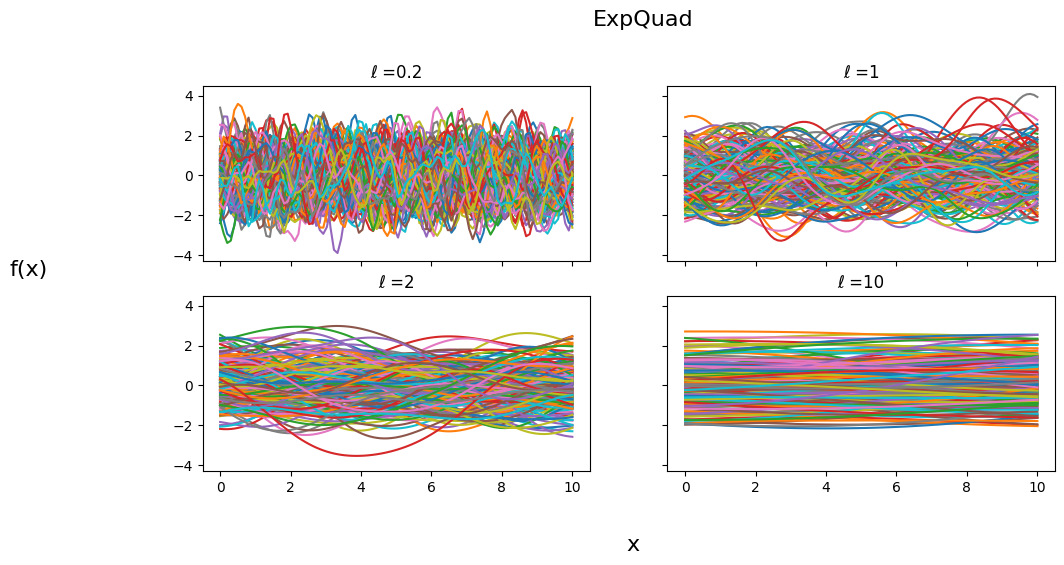

In [ ]:
np.random.seed(24)
test_points = np.linspace(0, 10, 100)[:,None]
fig, ax = plt.subplots(2, 2, figsize=(11, 5), sharex=True, sharey=True)
ax = np.ravel(ax)

for idx, ℓ in enumerate((0.2, 1, 2, 10)):
    cov = pm.gp.cov.ExpQuad(input_dim=1, ls=ℓ)
    ax[idx].plot(test_points, pz.MvNormal(mu=np.zeros_like(test_points)[:,0],
                                          cov=cov(test_points).eval()).rvs(200).T)
    ax[idx].set_title(f'ℓ ={ℓ}')
fig.text(0.48, 1, 'ExpQuad', fontsize=16)
fig.text(0.51, -0.05, 'x', fontsize=16)
fig.text(-0.05, 0.5, 'f(x)', fontsize=16)
plt.show()

A diferencia de lo observado en el módulo, en donde las dos realizaciones del Kernel entraban en el rango $[-2, 2]$, **aquí podemos ver que el rango se amplifica un poco**. Aquí la mayoría se sigue concentrando en el rango $[-2, 2]$, pero hay algunas realizaciones que se salen de los bordes del intervalo y pueden llegar a tocar los bordes del intervalo $[-4, 4]$. Cuando la longitud de escala ℓ es mayor (mirar el caso de ℓ=10) podemos ver que las realizaciones viven estrictamente en el rango $[-2, 2]$.

### 3. Para el gráfico generado en el ejercicio anterior, calcule la desviación estándar para los valores en cada punto. Hazlo de la siguiente forma:

* Visualmente, simplemente observando los gráficos

* Directamente a partir de los valores generados a partir de `pz.MVNormal(.).rvs`

* Inspeccionando la matriz de covarianza (si tienes dudas, vuelve al ejercicio 1)
¿Coincidieron los valores que obtuviste de estos tres métodos?

Primero empezamos por guardar los valores de las realizaciones generadas:

In [ ]:
cov = pm.gp.cov.ExpQuad(input_dim=1, ls=ℓ)
realizaciones = pz.MvNormal(mu=np.zeros_like(test_points)[:,0], cov=cov(test_points).eval()).rvs(200)
realizaciones.shape

(200, 100)

Podemos ver que tenemos 200 filas y 100 columnas, es decir que hay 200 realizaciones para cada punto generado. En este caso esperamos que la desviación estándar sea de 1 para que coincida con lo visto en el gráfico, ya que en el mismo se mostraba que las realizaciones estaban centradas en cero y al provenir de una distribución normal multivariada estas se condensan en su mayoría entre 2 y -2 desviaciones estándar, que es justamente con el intervalo $[-2, 2]$ que observamos.

Vamos a calcular la desviación estándar empírica (a partir de las muestras aleatorias) y teórica (inspeccionando matriz de covarianza) para cada punto:

In [ ]:
# sd empírica por punto (a través de las realizaciones)
sd_emp = realizaciones.std(axis=0, ddof=1)

# sd teórica por punto desde el kernel (diagonal de K)
K = cov(test_points).eval()
sd_teo = np.sqrt(np.diag(K))

print(f"sd empírica por punto — media: {sd_emp.mean():.3f}, min: {sd_emp.min():.3f}, max: {sd_emp.max():.3f}")
print(f"sd teórica por punto — media: {sd_teo.mean():.3f}, min: {sd_teo.min():.3f}, max: {sd_teo.max():.3f}")

sd empírica por punto — media: 0.997, min: 0.986, max: 1.019
sd teórica por punto — media: 1.000, min: 1.000, max: 1.000


En ambos casos los resultados son bastante similares, en el caso teórico sabemos que iba a devolver 1 por como está definido el Kernel y por lo visto en el ejercicio 1. Luego en el cálculo empírico vemos que los valores promedio, máximo y minimo también están bastante cercanos. Las discrepancias observadas son normales dada la aleatoriedad implícita en el proceso de generación de muestras.

Finalmente podemos visualizar un gráfico para ver con más detalle las diferencias:

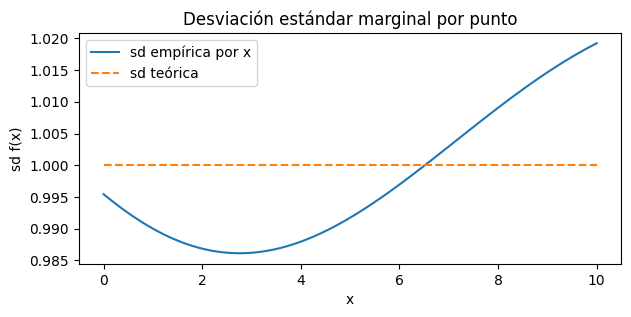

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(test_points[:, 0], sd_emp, label='sd empírica por x')
ax.plot(test_points[:, 0], sd_teo, '--', label='sd teórica')
ax.set_xlabel('x'); ax.set_ylabel('sd f(x)'); ax.legend()
ax.set_title('Desviación estándar marginal por punto')
plt.show()

### 4. Usa los puntos de prueba `np.linspace(np.floor(x.min()), 20, 100)[:,None]` y vuelve a ejecutar `model_reg`. Grafica los resultados. ¿Qué observaste? ¿Cómo se relaciona esto con la especificación de la prior GP?

Empezamos por generar los datos sintéticos con los cuales se especificó a `model_reg`:

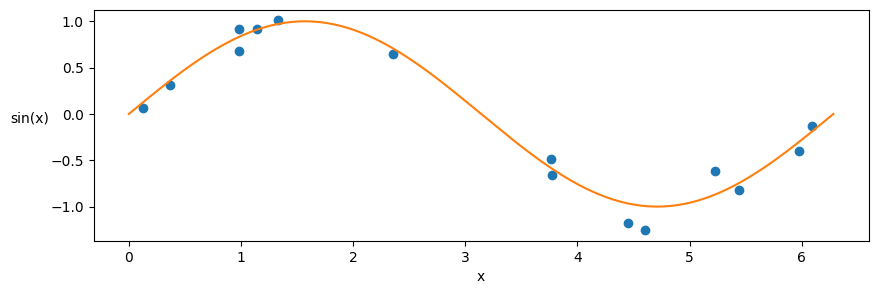

In [10]:
np.random.seed(42)
x = np.random.uniform(0, 2 * np.pi, size=15)
y = np.random.normal(np.sin(x), 0.1)


_, ax = plt.subplots(figsize=(10, 3))
ax.plot(x, y, 'o')
true_x = np.linspace(0, 2 * np.pi, 200)
ax.plot(true_x, np.sin(true_x), 'C1')
ax.set_xlabel('x')
ax.set_ylabel('sin(x)', rotation=0, labelpad=15)
plt.show()

Volvemos a construir el mismo modelo:

In [11]:
# Se espera que X tenga dimensión 2, incluso si lo tenemos una variable/feature
X = x[:,None]

with pm.Model() as modelo_reg:
    # hyperprior para la longitud de escala
    ℓ = pm.Exponential("ℓ", 0.5)

    # instanciamos la función de covarianza
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    # instanciamos el GP (prior)
    gp = pm.gp.Marginal(cov_func=cov)

    σ = pm.HalfNormal('σ', 25)

    y_pred = gp.marginal_likelihood('y_pred', X=X, y=y, sigma=σ)
    idata_reg = pm.sample(random_seed=123, target_accept=0.99)

Output()

Y ahora cambiamos los puntos de prueba por los propuestos en el enunciado:

In [12]:
X_new = np.linspace(np.floor(x.min()), 20, 100)[:,None]

with modelo_reg:
    f_pred = gp.conditional('f_pred', X_new)

Notar que estos puntos de prueba lo que hacen es "ir más allá" de el rango observado para los datos. Podemos notar en el primer gráfico que se hizo al generar los datos que el rango estaba entre 0 y un poco más de 6, ahora el rango llega hasta 20. Vamos a ver como se comporta el modelo y para eso generamos predicciones:

In [13]:
with modelo_reg:
    idata_reg_subset = idata_reg.sel(draw=slice(0, None, 100))
    pred_samples = pm.sample_posterior_predictive(idata_reg_subset,
                                                  var_names=["f_pred"],
                                                  random_seed=123)

f_pred = az.extract(pred_samples, group="posterior_predictive")['f_pred']

Output()

Generamos el gráfico de las funciones resultantes:

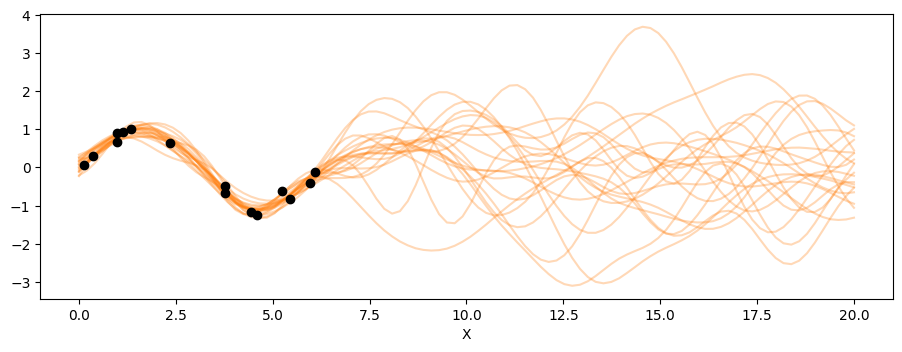

In [14]:
_, ax = plt.subplots(figsize=(11, 3.7))
ax.plot(X_new, f_pred, 'C1-', alpha=0.3)
ax.plot(X, y, 'ko')
ax.set_xlabel('X');

Y aquí está la diferencia y el peso que tiene el prior GP. En el rango del 0 hasta poco más del 6 el comportamiento es similar al observado en el ejemplo del módulo, las funciones generadas se ajustan bien a los puntos. Luego para los valores posteriores al 6 vemos que directamente no hay datos observados y ahí lo único que "juega" es el prior especificado, el cual es un Kernel exponencial cuadrático. Podemos ver que mantiene la misma forma suave pero ahora las funciones generadas cuentan con más "ruido" o no están tan concentradas.

### 5. Repite el ejercicio 1, pero esta vez usa un kernel lineal.

En este caso se va a generar un código generador de datos similar al del ejercicio 1, pero ahora incluyendo a la función `linear_kernel` para representar al Kernel lineal:

In [ ]:
def linear_kernel(x, xi, σ_b=1, σ=1, c=0):
    """kernel lineal"""
    return np.array([σ_b**2 + σ**2 * (x - c) * (x_i - c) for x_i in xi])


labels = ["A", "B", "C", "D"]
datos = np.random.normal(size=4)
cov = linear_kernel(datos, datos, σ_b=1, σ=1, c=0)

Ahora pasamos a generar un gráfico usando el mismo código del ejercicio 1:

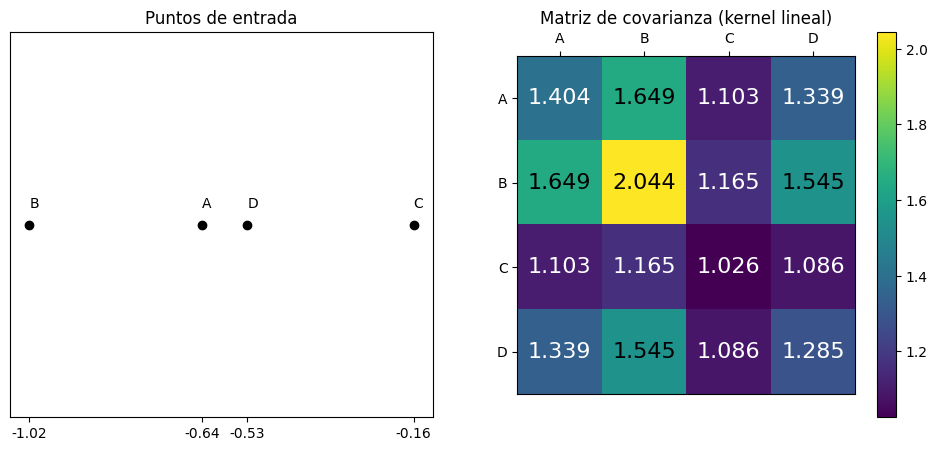

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = np.ravel(ax)

ax[0].plot(datos, np.zeros_like(datos), 'ko')
ax[0].set_yticks([])
for i, l in zip(datos, labels):
    ax[0].text(i, 0+0.005, l)
ax[0].set_xticks(datos)
ax[0].set_xticklabels(np.round(datos, 2))
ax[0].set_title('Puntos de entrada')

ax[1].grid(False)
im = ax[1].imshow(cov, vmin=np.min(cov), vmax=np.max(cov))
colors = ['w', 'k']
for i in range(len(cov)):
    for j in range(len(cov)):
        text_val = round(cov[i, j], 3)
        ax[1].text(j, i, text_val,
                   color=colors[int(im.norm(cov[i, j]) > 0.5)],
                   ha='center', va='center', fontdict={'size': 16})
ax[1].set_xticks(range(len(datos)), labels)
ax[1].set_yticks(range(len(datos)), labels)
ax[1].xaxis.tick_top()
ax[1].set_title('Matriz de covarianza (kernel lineal)')
fig.colorbar(im, ax=ax[1])

plt.show()

Aquí podemos ver las diferencias con respecto al Kernel cuadrático exponencial. La primera diferencia a notar es la **diagonal de la matriz de correlación**, en donde los valores no son todos 1 sino que toman valores mayores. Esto es debido a que en el Kernel lineal la varianza de una observación crece a medida de que esta se aleja de un punto central, que en este caso es el 0. Podríamos relacionarlo a como se mide la varianza tradicionalmente, en donde se mide que tanto un punto se aleja de la media de los datos.

En cuanto a la covarianza esta es la que mide la relación entre dos puntos, pero **a diferencia del Kernel exponencial cuadrático esta no se mide por distancias sino por direcciones de cambio**. Dos puntos pueden estar alejados entre sí, pero si están en la misma "linea" (recordar a los vectores que se veían en geometría) entonces tienen una fuerte correlación ya que ambos se mueven en la misma dirección. Vamos a pensarlo utilizando la ecuación que define al Kernel, la cual es la siguiente:

$$k(t, t') = \sigma_b^2 + \sigma^2(t-c)(t'-c)$$

Para un primer caso asumamos los valores $t=2$, $t' = 6$, $c=0$, $\sigma^2 = 1$ y $\sigma_b^2 = 1$:

$$k(t, t') = 1 + 1(2-0)(6-0) = 1 + 2.6 = 12$$

Podemos ver una correlación alta, lo que indica una relación positiva entre los puntos. Ahora mantengamos todo igual pero asumamos que los puntos siguen direcciones opuestas ($t=2$, $\tilde{t} = -2$,):

$$k(t, t') = 1 + 1(2-0)(-2-0) = 1 + 2.-2 = -4$$

Ahora la correlación disminuye y toma un valor negativo, eso significa que los datos tienen una relación negativa: **cuando uno aumenta el otro disminuye**.

### 6. Consulta [Funciones de Media y Covarianza](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MeansAndCovs.html) en la documentación de PyMC.

En la documentación propuesta por el enunciado se puede ver a detalle como funcionan las funciones de media y covarianza en PyMC, qué podemos hacer con ellas y cúales son sus límites. En la parte de las funciones de media no hay mucha variedad ya que usualmente en procesos Gaussianos se asume que la media es cero para simplificar cuentas. Luego para las funciones de covarianza hay una gran variedad, es posible combinar funciones ya sea multiplicandolas o sumandolas entre sí, definir "wrappers" para modificar la entrada e incluso construir Kernels propios. Esto añade una gran flexibilidad a la hora de modelar datos haciendo uso de procesos Gaussianos.

### 7. Ejecuta un modelo de regresión logística para los datos de `gripe_espacial`. ¿Qué ves? ¿Puedes explicar el resultado?

Empezamos por cargar los datos utilizados:

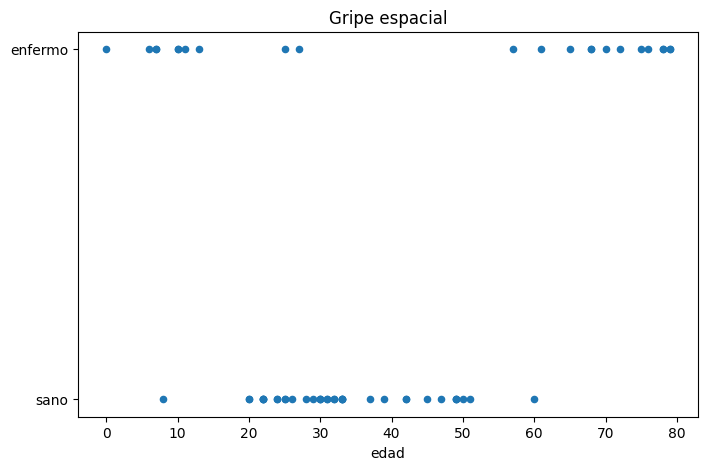

In [16]:
df_sf = pd.read_csv('gripe_espacial.csv')
age = df_sf.age.values[:, None]
space_flu = df_sf.space_flu

ax = df_sf.plot.scatter('age', 'space_flu', figsize=(8, 5))
ax.set_ylabel("")
ax.set_xlabel("edad")
ax.set_title("Gripe espacial")
ax.set_yticks([0, 1])
ax.set_yticklabels(['sano', 'enfermo'])
plt.show()

Ahora definimos un modelo de regresión logística para los datos de `gripe_espacial` utilizando Bambi para simplificar las cosas:

In [31]:
modelo_gripe_espacial = bmb.Model("space_flu ~ age", df_sf, family="bernoulli")
idata_gripe = modelo_gripe_espacial.fit()

Output()

Ahora generamos un gráfico del ajuste del modelo a los datos y sus predicciones:

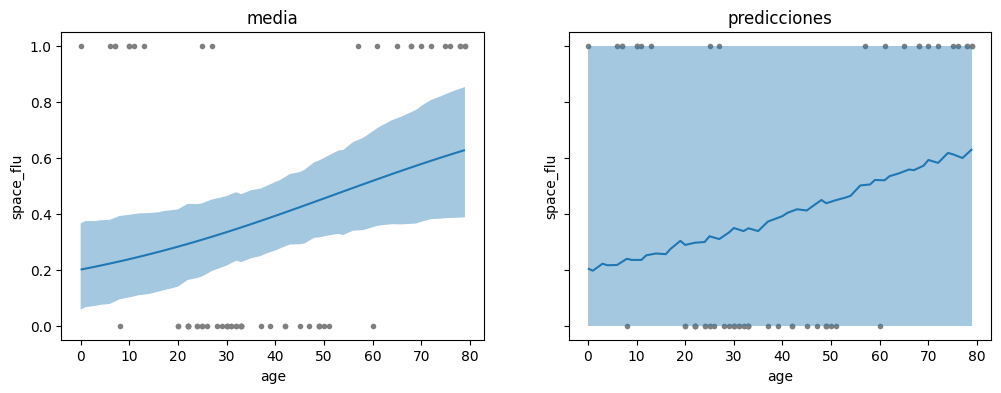

In [35]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(modelo_gripe_espacial, idata_gripe, "age", ax=axes[0])
bmb.interpret.plot_predictions(modelo_gripe_espacial, idata_gripe, "age", pps=True, ax=axes[1])

axes[0].plot(df_sf.age, df_sf.space_flu, ".", color="0.5",  zorder=-3)
axes[1].plot(df_sf.age, df_sf.space_flu, ".", color="0.5", zorder=-3)
axes[0].set_title("media")
axes[1].set_title("predicciones")
plt.show()

En el resultado podemos ver que la media de la distribución *a posteriori* parece ser más una recta que la forma de S que tiene la función sigmoide que identifica a una regresión logística. Esto es debido a que este modelo intenta ajustar a los datos pasando por el medio de los mismos, pero al tener esta particularidad de contar con dos "regiones altas" y una "región baja" el modelo no sabe que hacer y opta por tomar la forma observada.

### 8. Cambia el modelo de regresión logística para que se ajuste a los datos. Consejo: usa un polinomio de orden 2.

Con los datos cargados desde el ejercicio anterior, volvemos a utilizar Bambi para ajustar un modelo polinomial de orden 2:

In [37]:
modelo_gripe_espacial_poly2 = bmb.Model("space_flu ~ poly(age,2)", df_sf)
idata_gripe_2 = modelo_gripe_espacial_poly2.fit()

Output()

Ahora generamos un gráfico del ajuste del modelo a los datos y sus predicciones:

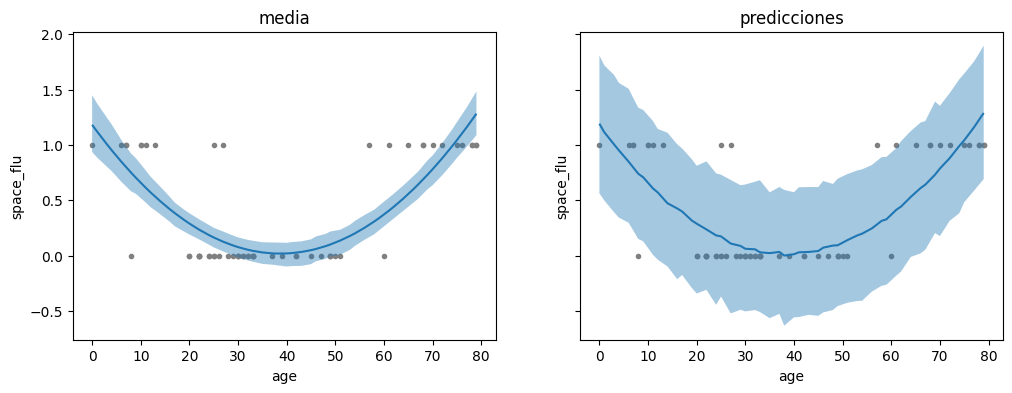

In [38]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(modelo_gripe_espacial_poly2, idata_gripe_2, "age", ax=axes[0])
bmb.interpret.plot_predictions(modelo_gripe_espacial_poly2, idata_gripe_2, "age", pps=True, ax=axes[1])

axes[0].plot(df_sf.age, df_sf.space_flu, ".", color="0.5",  zorder=-3)
axes[1].plot(df_sf.age, df_sf.space_flu, ".", color="0.5", zorder=-3)
axes[0].set_title("media")
axes[1].set_title("predicciones")
plt.show()

Aquí el ajuste mejoró bastante, y era de esperarse ya que a grandes rasgos estos datos conforman una forma de U y eso justamente se puede modelar usando una función cuadrática. Sin embargo aquí se puede notar una diferencia clave con la flexibilidad y sutileza con la que cuentan los procesos Gaussianos, en el ejemplo mostrado en el módulo donde se utilizó un Kernel exponencial cuadrático para modelar a los mismos datos podíamos ver como en las regiones altas el modelo "bajaba" la curva para ajustarse a los datos. Aquí podemos ver como el polinomio si bien llega a las regiones más altas, luego las pasa de largo y eso lleva a una extrapolación que a lo mejor no nos interesa.

### 9. Compara el modelo para el desastre de la minería de carbón con el de la [documentación de PyMC](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html#case-study-2-coal-mining-disasters). Describe las diferencias entre ambos modelos en términos de especificación del modelo y resultados.

Para realizar la comparación de ambos modelos únicamente voy a copiar el código PyMC que construye a ambos modelos. El gráfico del modelo basado en procesos Gaussianos para estos datos se encuentra en el módulo y el gráfico del modelo perteneciente a la documentación de PyMC se encuentra en el enlace referenciado en el enunciado.

Empiezo por la versión de la documentación de PyMC:

In [ ]:
with pm.Model() as disaster_model:
    switchpoint = pm.DiscreteUniform("switchpoint", lower=years.min(), upper=years.max())

    # Priors for pre- and post-switch rates number of disasters
    early_rate = pm.Exponential("early_rate", 1.0)
    late_rate = pm.Exponential("late_rate", 1.0)

    # Allocate appropriate Poisson rates to years before and after current
    rate = pm.math.switch(switchpoint >= years, early_rate, late_rate)

    disasters = pm.Poisson("disasters", rate, observed=disaster_data)

Copio la versión vista en el módulo:

In [ ]:
with pm.Model() as modelo_minas:
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(x_edges))
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ) + pm.gp.cov.WhiteNoise(1E-5)
    gp = pm.gp.Latent(cov_func=cov)
    f = gp.prior('f', X=x_data)

    y_pred = pm.Poisson('y_pred', mu=pm.math.exp(f), observed=y_data)
    idata_minas = pm.sample(random_seed=123)

Para `disaster_model` tenemos que el foco principal es identificar el punto de cambio, eso hace que a los períodos antes y despúes del cambio se le asignen priors uniformes. Esto se traduce en que a la hora de visualizar los resultados veamos unas rectas horizontales en ambos periodos, y la parte "curva" ocurre durante la etapa de cambio.

Luego para `modelo_minas` podemos observar un ajuste más "suave" hacia los datos, cosa que es de esperarse dada la inclusión del Kernel exponencial cuadrático como prior. Aquí la diferencia radica en la suavidad que ya mencionamos, pero a la vez perdemos esa identificación tan clara del punto de cambio. Esto hace que el uso de una versión del modelo u otra dependa exclusivamente de qué es lo que nos interesa.